In [20]:
# Enlarge markdown rendering for presentation mode.
# Non-invasive — pure CSS injection, no markdown content is changed.
# Works in both JupyterLab and classic Notebook. Comment out to revert.
from IPython.display import HTML, display
display(HTML("""
<style>
.jp-RenderedMarkdown, .rendered_html {
    font-size: 20px;
    line-height: 1.55;
}
.jp-RenderedMarkdown h1, .rendered_html h1 { font-size: 2.1em; }
.jp-RenderedMarkdown h2, .rendered_html h2 { font-size: 1.7em; }
.jp-RenderedMarkdown h3, .rendered_html h3 { font-size: 1.35em; }
.jp-RenderedMarkdown code, .rendered_html code { font-size: 0.95em; }
.jp-RenderedMarkdown table, .rendered_html table { font-size: 0.95em; }
</style>
"""))

# Guided Label Propagation — Tool Demo
*Semi-supervised community detection for large-scale information-sharing networks.*

**Motivation** — When you have a messy information sharing network with many nodes and only solid knowledge about a fraction of them.

**Unique features**
- ⚡ Fast (and memory efficient) on large data using Polars + NetworkIt + streamlined backboning
- 🎯 Intuitive regularization via noise category — interpretable regularization knob
- 📊 Full-attribute export — labels · probs · noise → Gephi GEXF
- 🔁 Mulitple network configurations: Directed + undirected - weighted + unweighted - bipartite + unipartite

## Sections
§2 Math · §3 Tool intuition · §4 Demonstration using real world data (+ validation) · §5 Cross-domain demonstration (+ validation) · §6 Viz + Gephi

## Input examples
**Dataframe**
`acccount` · `url` · [`counts`· `timestamp`]

**Other Dataframes**  
`acccount` · `domain`  
`acccount` · `keyword`  
`acccount` · `account` · `embedding similarity`  

## 2. Math & architecture

$$F^{(t+1)} = \alpha \, P \, F^{(t)} + (1-\alpha)\, Y \qquad P = D^{-1}A$$

- $Y$ — seed indicator · $P$ — row-normalized transition · $\alpha$ — neighbor weight (0.85)
- $(1{-}\alpha)Y$ anchor → seeds stay pinned throughout
- Convergence: $\max\Delta F < 10^{-6}$ — usually <30 iters

**Canonical pipeline** — raw → bipartite EdgeList → SVN backbone → temporal projection (directed) → noise-corrected backbone. Three memory modes (`fast` / `balanced` / `low`).

In [21]:
"""All imports for the rest of the notebook."""
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning, module=r"guidedLP\..*")

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkit as nk

# Public guidedLP API
from guidedLP.common.id_mapper import IDMapper
from guidedLP.common.seed_input import normalize_seed_input
from guidedLP.network.construction import (
    build_graph_from_edgelist,
    edgelist_to_graph,
)
from guidedLP.network.communities import detect_communities
from guidedLP.network.reduction import export_reduced_graph
from guidedLP.network.filtering import filter_by_seed_proximity
from guidedLP.glp import winsorize_transform
from guidedLP.glp import (
    guided_label_propagation,
    ensemble_label_propagation,
    train_test_split_validation,
    get_validation_summary,
    make_stat_user_edges,
    get_seed_statistics,
    check_seed_coverage,
    GLPGridSearch,
)

import logging
logging.getLogger("guidedLP").setLevel(logging.ERROR)
# Internal helpers — used in Section 3 only, to capture per-iteration F.
# Not stable API; OK for a sketch.
from guidedLP.glp.propagation import (
    _initialize_label_matrix,
    _create_transition_matrix,
    _generate_noise_seeds,
)
from guidedLP.pipelines import run_canonical_pipeline

# Optional: NetworkX (for spring layout).
try:
    import networkx as nx
    HAS_NX = True
except ImportError:
    HAS_NX = False

# Jupyter display helper; degrades gracefully outside a kernel.
try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore[assignment]

warnings.filterwarnings("ignore", category=UserWarning, module="networkit")
#print(f"networkx: {'yes' if HAS_NX else 'no'}")


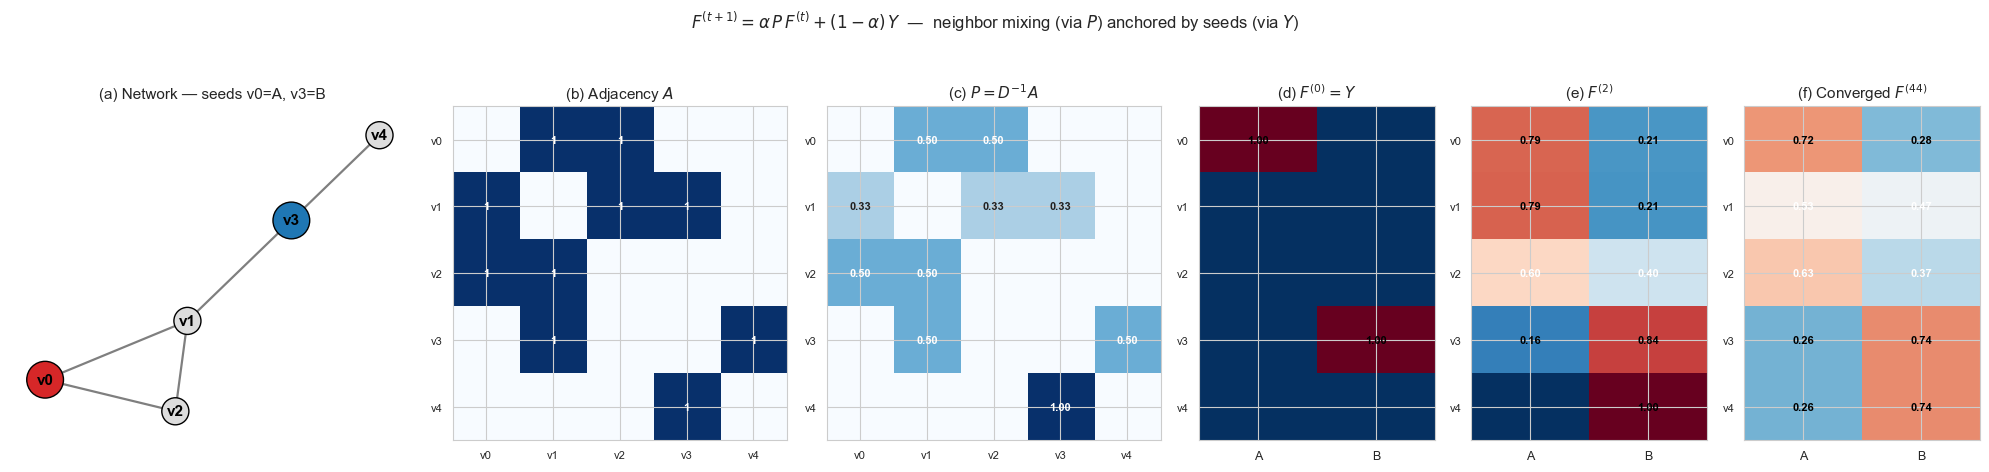

In [22]:
# Algorithm at a glance — 5-node graph + matrices + iterations of F.
# Visualises F^(t+1) = α P F^(t) + (1-α) Y on the smallest possible example.

import matplotlib.gridspec as gridspec
import networkx as nx

_edges = [(0, 1), (0, 2), (1, 2), (3, 4), (1, 3)]
_n = 5
_alpha = 0.85

# Adjacency + transition + seeds
_A = np.zeros((_n, _n))
for u, v in _edges:
    _A[u, v] = 1.0; _A[v, u] = 1.0
_P = (_A.T / _A.sum(axis=1)).T
_Y = np.zeros((_n, 2))
_Y[0, 0] = 1.0      # v0 → A
_Y[3, 1] = 1.0      # v3 → B

# Propagate, capture snapshots
_F = _Y.copy()
_snaps = [_F.copy()]
for _ in range(60):
    _F_next = _alpha * _P @ _F + (1 - _alpha) * _Y
    _snaps.append(_F_next.copy())
    if np.abs(_F_next - _F).max() < 1e-6:
        _F = _F_next
        break
    _F = _F_next
_conv = len(_snaps) - 1

# Layout
_G = nx.Graph(_edges)
_pos = nx.spring_layout(_G, seed=42)
_labels_F = ["A", "B"]

# === Figure ===
fig = plt.figure(figsize=(20, 4.5))
gs = gridspec.GridSpec(1, 6, figure=fig, width_ratios=[1.2, 1, 1, 0.7, 0.7, 0.7])

# Panel (a) — network
ax = fig.add_subplot(gs[0, 0])
_seeds = {0: "A", 3: "B"}
_node_color = ["#d62728" if i == 0 else "#1f77b4" if i == 3 else "#dddddd"
               for i in range(_n)]
_node_size  = [700 if i in _seeds else 380 for i in range(_n)]
nx.draw_networkx_edges(_G, _pos, ax=ax, width=1.6, alpha=0.5)
nx.draw_networkx_nodes(_G, _pos, ax=ax, node_color=_node_color,
                       node_size=_node_size, edgecolors="black", linewidths=1)
nx.draw_networkx_labels(_G, _pos, ax=ax, font_size=11, font_weight="bold",
                        labels={i: f"v{i}" for i in range(_n)})
ax.set_title("(a) Network — seeds v0=A, v3=B", fontsize=11)
ax.axis("off")

# Panels (b) A, (c) P
for axi, mat, title in [
    (fig.add_subplot(gs[0, 1]), _A, r"(b) Adjacency $A$"),
    (fig.add_subplot(gs[0, 2]), _P, r"(c) $P = D^{-1} A$"),
]:
    axi.imshow(mat, cmap="Blues", vmin=0,
               vmax=max(0.1, mat.max()), aspect="equal")
    axi.set_xticks(range(_n)); axi.set_yticks(range(_n))
    axi.set_xticklabels([f"v{i}" for i in range(_n)], fontsize=8)
    axi.set_yticklabels([f"v{i}" for i in range(_n)], fontsize=8)
    for i in range(_n):
        for j in range(_n):
            v = mat[i, j]
            if v > 0:
                txt = "1" if title.startswith("(b)") else f"{v:.2f}"
                color = "white" if v / max(mat.max(), 1e-9) > 0.4 else "#222"
                axi.text(j, i, txt, ha="center", va="center",
                         fontsize=8, color=color, fontweight="bold")
    axi.set_title(title, fontsize=11)

# Panels (d)–(f) — F at t=0, t=2, converged
_iter_at = [0, 2, _conv]
_titles  = [r"(d) $F^{(0)} = Y$",
            r"(e) $F^{(2)}$",
            rf"(f) Converged $F^{{({_conv})}}$"]
for col, (it, ttl) in enumerate(zip(_iter_at, _titles), start=3):
    axi = fig.add_subplot(gs[0, col])
    _Fi = _snaps[it]
    _rs = _Fi.sum(axis=1, keepdims=True)
    _Fn = np.where(_rs > 0, _Fi / np.maximum(_rs, 1e-12), 0.0)
    axi.imshow(_Fn, cmap="RdBu_r", vmin=0, vmax=1, aspect="auto")
    axi.set_xticks([0, 1])
    axi.set_xticklabels(_labels_F, fontsize=9)
    axi.set_yticks(range(_n))
    axi.set_yticklabels([f"v{i}" for i in range(_n)], fontsize=8)
    axi.set_title(ttl, fontsize=11)
    for i in range(_n):
        for j in range(2):
            v = _Fn[i, j]
            if v > 0.03:
                axi.text(j, i, f"{v:.2f}", ha="center", va="center",
                         fontsize=8,
                         color="white" if 0.3 < v < 0.7 else "black",
                         fontweight="bold")

fig.suptitle(r"$F^{(t+1)} = \alpha \, P \, F^{(t)} + (1-\alpha)\, Y$  —  "
             "neighbor mixing (via $P$) anchored by seeds (via $Y$)",
             fontsize=12, y=1.04)
plt.tight_layout()
plt.show()

## 3. The algorithm at work
- **3a** — clean two-community (90 nodes) — propagation mechanic via iteration snapshots
- **3b** — three-community + stragglers — role of noise category, with vs without

In [23]:
# Define toy graph
def build_toy_graph(rng_seed: int = 0, community_size: int = 45):
    """Two communities, sparse intra-community edges, a handful of bridges."""
    rng = np.random.default_rng(rng_seed)
    n = 2 * community_size
    g = nk.Graph(n, weighted=True, directed=False)

    p_intra = 0.15
    for i in range(community_size):
        for j in range(i + 1, community_size):
            if rng.random() < p_intra:
                g.addEdge(i, j, w=1.0)
            if rng.random() < p_intra:
                g.addEdge(i + community_size, j + community_size, w=1.0)

    # Half a dozen bridge edges between the two communities.
    n_bridges = 6
    a_picks = rng.choice(community_size, size=n_bridges, replace=False)
    b_picks = rng.choice(community_size, size=n_bridges, replace=False) + community_size
    for u, v in zip(a_picks, b_picks):
        g.addEdge(int(u), int(v), w=1.0)

    mapper = IDMapper.from_originals([f"n{i:02d}" for i in range(n)])
    return g, mapper, community_size

toy_graph, toy_mapper, COMM_SZ = build_toy_graph()
toy_seeds = {
    "n00": "left",  "n01": "left",  "n02": "left",
    f"n{COMM_SZ:02d}": "right", f"n{COMM_SZ+1:02d}": "right", f"n{COMM_SZ+2:02d}": "right",
}
toy_labels = ["left", "right"]
print(f"Toy graph: {toy_graph.numberOfNodes()} nodes "
      f"({COMM_SZ} per community), "
      f"{toy_graph.numberOfEdges()} edges, "
      f"{len(toy_seeds)} seeds (3 per community)")


Toy graph: 90 nodes (45 per community), 311 edges, 6 seeds (3 per community)


In [24]:
# Simulate propagation
def propagate_with_snapshots(graph, mapper, seeds, labels,
                             alpha: float = 0.85,
                             max_iterations: int = 60,
                             tol: float = 1e-6):
    """Run the GLP fixed-point and return [F_0, F_1, ..., F_T].

    F_0 is the seed matrix Y. F_t for t>=1 is the post-iteration state.
    Same update as guided_label_propagation but keeps every snapshot.
    """
    Y = _initialize_label_matrix(graph, mapper, seeds, labels)
    P = _create_transition_matrix(graph, direction="out_degree")
    F = Y.copy()
    snapshots = [F.copy()]
    for _ in range(max_iterations):
        F_next = alpha * (P @ F) + (1.0 - alpha) * Y
        delta = float(np.abs(F_next - F).max())
        F = F_next
        snapshots.append(F.copy())
        if delta < tol:
            break
    return snapshots

snapshots = propagate_with_snapshots(toy_graph, toy_mapper, toy_seeds, toy_labels)
print(f"Converged after {len(snapshots) - 1} iterations "
      f"(captured {len(snapshots)} snapshots including t=0).")


Converged after 38 iterations (captured 39 snapshots including t=0).


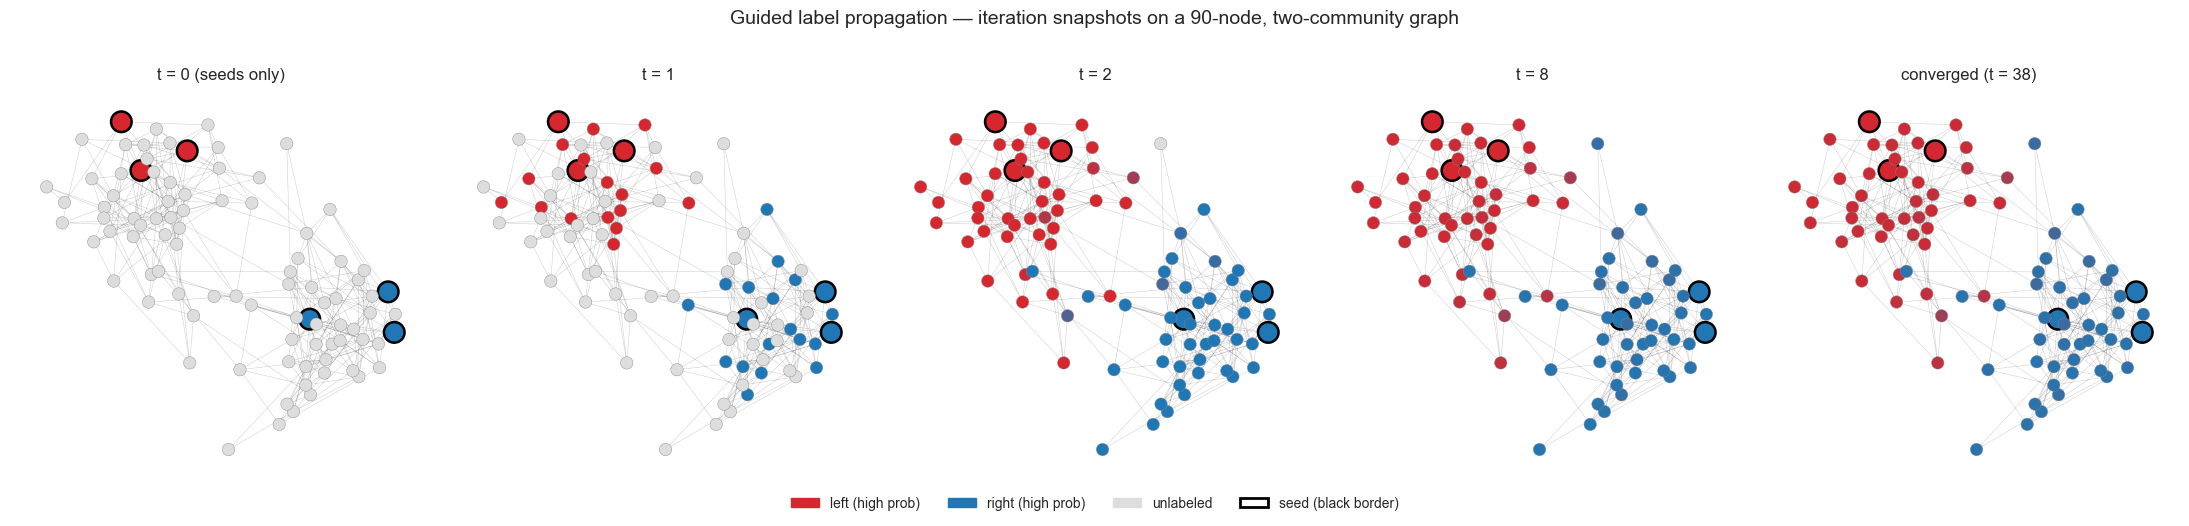

In [25]:
#Build Toy Graph Example
G = nx.Graph()
for i in range(toy_graph.numberOfNodes()):
    G.add_node(toy_mapper.get_original(i))
for u, v in toy_graph.iterEdges():
    G.add_edge(toy_mapper.get_original(u), toy_mapper.get_original(v))
pos = nx.spring_layout(G, seed=42, k=0.5)

converged_idx = len(snapshots) - 1
panel_indices = [0, 1, 2, 8, converged_idx]
panel_titles = ["t = 0 (seeds only)", "t = 1", "t = 2", "t = 8",
                f"converged (t = {converged_idx})"]

seed_set = set(toy_seeds.keys())
color_left  = np.array([0.84, 0.15, 0.18])  # red
color_right = np.array([0.12, 0.47, 0.71])  # blue

fig, axes = plt.subplots(1, 5, figsize=(22, 4.8))
for ax, t_idx, title in zip(axes, panel_indices, panel_titles):
    F = snapshots[t_idx]
    row_sums = F.sum(axis=1, keepdims=True)
    F_norm = np.where(row_sums > 0, F / np.maximum(row_sums, 1e-12), 0.0)

    node_ids = [toy_mapper.get_original(i) for i in range(toy_graph.numberOfNodes())]
    colors, sizes, edgecolors, linewidths = [], [], [], []
    for i, nid in enumerate(node_ids):
        if F_norm[i].sum() == 0:
            colors.append("#dddddd")
        else:
            blended = F_norm[i, 0] * color_left + F_norm[i, 1] * color_right
            colors.append(tuple(np.clip(blended, 0, 1)))
        sizes.append(220 if nid in seed_set else 80)
        edgecolors.append("black" if nid in seed_set else "#888")
        linewidths.append(1.8 if nid in seed_set else 0.3)

    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.18, width=0.4)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=sizes,
                           edgecolors=edgecolors, linewidths=linewidths)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

legend_elements = [
    mpatches.Patch(color=tuple(color_left),  label="left (high prob)"),
    mpatches.Patch(color=tuple(color_right), label="right (high prob)"),
    mpatches.Patch(color="#dddddd",          label="unlabeled"),
    mpatches.Patch(facecolor="white", edgecolor="black", linewidth=2,
                   label="seed (black border)"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.05), frameon=False)
fig.suptitle(f"Guided label propagation — iteration snapshots on a "
             f"{toy_graph.numberOfNodes()}-node, two-community graph",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 3b. Messier graph — noise category in action

**Setup** — 90 nodes · 2 seeded communities · 1 unseeded fringe · 15 low-degree stragglers

**Two runs**
- `enable_noise_category=False` → every node forced into left/right
- `enable_noise_category=True, noise_ratio=0.7`, ensemble n=20 → distant regions → noise

In [26]:
# Define messy graph 
def build_messy_graph(rng_seed: int = 1):
    """Three-community + straggler graph that mirrors real-world messiness.

    Community A (30 nodes): seeded "left".
    Community B (30 nodes): seeded "right".
    Community C (15 nodes): unlabelled "fringe" — no seeds at all.
    Stragglers (15 nodes): low-degree, connected to 1-3 random anchors.
    Sparse cross-community bridges add realistic noise.
    """
    rng = np.random.default_rng(rng_seed)
    n_a, n_b, n_c, n_s = 30, 30, 15, 15
    n_total = n_a + n_b + n_c + n_s
    g = nk.Graph(n_total, weighted=True, directed=False)

    # Intra-community edges — slight density differences.
    ranges = {
        "a": (0, n_a, 0.18),
        "b": (n_a, n_a + n_b, 0.18),
        "c": (n_a + n_b, n_a + n_b + n_c, 0.30),
    }
    for name, (lo, hi, p) in ranges.items():
        for i in range(lo, hi):
            for j in range(i + 1, hi):
                if rng.random() < p:
                    g.addEdge(i, j, w=1.0)

    # Sparse cross-community bridges — only a handful per pair.
    def bridge(lo1, hi1, lo2, hi2, count):
        for _ in range(count):
            u = int(rng.integers(lo1, hi1))
            v = int(rng.integers(lo2, hi2))
            if u != v and not g.hasEdge(u, v):
                g.addEdge(u, v, w=1.0)

    bridge(0, n_a, n_a, n_a + n_b, count=5)                          # A-B
    bridge(0, n_a, n_a + n_b, n_a + n_b + n_c, count=2)              # A-C
    bridge(n_a, n_a + n_b, n_a + n_b, n_a + n_b + n_c, count=2)      # B-C

    # Stragglers: 1-3 connections each, mostly to A/B (rarely C).
    anchor_pool = list(range(0, n_a + n_b))     # most connect to seeded space
    fringe_pool = list(range(n_a + n_b, n_a + n_b + n_c))
    for s in range(n_a + n_b + n_c, n_total):
        deg = int(rng.choice([1, 1, 2, 3], p=[0.4, 0.3, 0.2, 0.1]))
        pool = anchor_pool if rng.random() < 0.7 else fringe_pool
        anchors = rng.choice(pool, size=min(deg, len(pool)), replace=False)
        for anchor in anchors:
            if not g.hasEdge(s, int(anchor)):
                g.addEdge(s, int(anchor), w=1.0)

    mapper = IDMapper.from_originals([f"m{i:02d}" for i in range(n_total)])
    return g, mapper, (n_a, n_b, n_c, n_s)

messy_graph, messy_mapper, (n_a, n_b, n_c, n_s) = build_messy_graph()
messy_seeds = {
    # 3 seeds in community A (left)
    "m00": "left", "m01": "left", "m02": "left",
    # 3 seeds in community B (right) — offset by n_a
    f"m{n_a:02d}": "right", f"m{n_a + 1:02d}": "right", f"m{n_a + 2:02d}": "right",
}
messy_labels = ["left", "right"]
print(f"Messy graph: {messy_graph.numberOfNodes()} nodes, "
      f"{messy_graph.numberOfEdges()} edges")
print(f"  Community A (left-seeded):     {n_a} nodes")
print(f"  Community B (right-seeded):    {n_b} nodes")
print(f"  Community C (fringe, no seeds): {n_c} nodes")
print(f"  Stragglers (low-degree):       {n_s} nodes")


Messy graph: 90 nodes, 212 edges
  Community A (left-seeded):     30 nodes
  Community B (right-seeded):    30 nodes
  Community C (fringe, no seeds): 15 nodes
  Stragglers (low-degree):       15 nodes


In [27]:
# Two GLP runs on the same graph — same seeds, only the noise category differs.
# The no-noise run is deterministic (single call). The with-noise run uses
# ensemble_label_propagation to average over 20 random noise placements —
# otherwise a single run's outcome depends on where the few noise seeds
# happen to land (the same variance reduction story we'll see in Section 5).

result_no_noise = guided_label_propagation(
    messy_graph, messy_mapper, messy_seeds, messy_labels,
    alpha=0.85, directional=False,
    enable_noise_category=False,
    verbose=False,
)

result_with_noise = ensemble_label_propagation(
    messy_graph, messy_mapper, messy_seeds, messy_labels,
    alpha=0.85, directional=False,
    enable_noise_category=True,
    noise_ratio=0.7,
    n_epochs=20, base_seed=42,
    verbose=False,
)

#print("Dominant-label distribution — WITHOUT noise category:")
#print(result_no_noise["dominant_label"].value_counts())
#print("\nDominant-label distribution — WITH noise category "
      #"(noise_ratio=0.7, ensemble n_epochs=20):")
#print(result_with_noise["dominant_label"].value_counts())


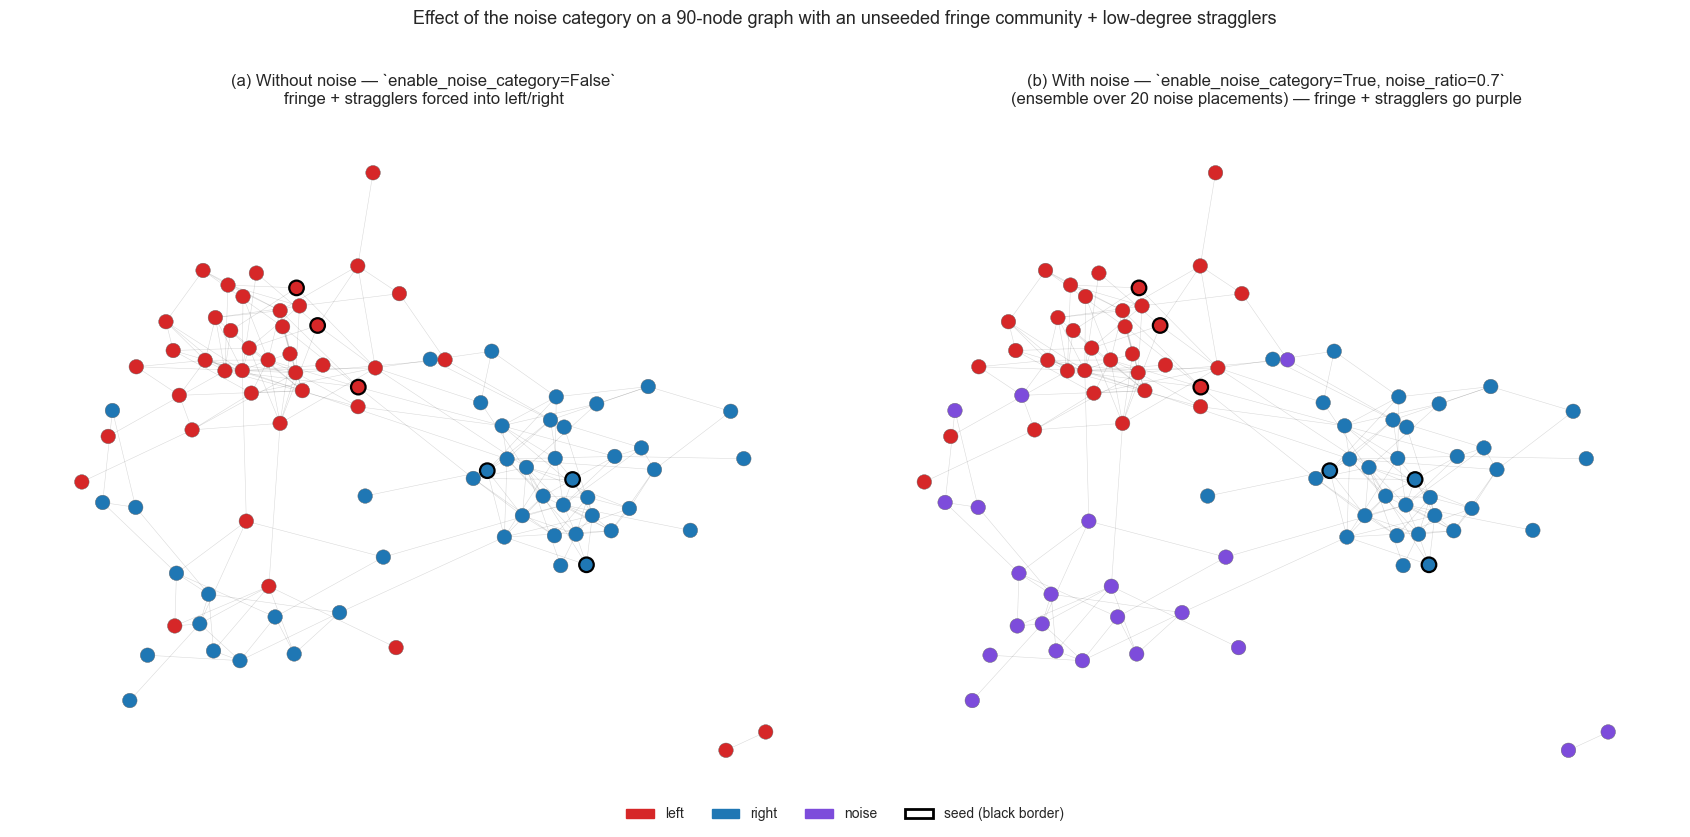

In [28]:
# Build messy graph example 
G_messy = nx.Graph()
for i in range(messy_graph.numberOfNodes()):
    G_messy.add_node(messy_mapper.get_original(i))
for u, v in messy_graph.iterEdges():
    G_messy.add_edge(messy_mapper.get_original(u), messy_mapper.get_original(v))
messy_pos = nx.spring_layout(G_messy, seed=42, k=0.35, iterations=80)

messy_seed_set = set(messy_seeds.keys())
palette = {"left": "#d62728", "right": "#1f77b4", "noise": "#7d4cdb"}
node_ids = [messy_mapper.get_original(i)
            for i in range(messy_graph.numberOfNodes())]

fig, axes = plt.subplots(1, 2, figsize=(17, 8))
for ax, result, title in [
    (axes[0], result_no_noise,
     "(a) Without noise — `enable_noise_category=False`\n"
     "fringe + stragglers forced into left/right"),
    (axes[1], result_with_noise,
     "(b) With noise — `enable_noise_category=True, noise_ratio=0.7`\n"
     "(ensemble over 20 noise placements) — fringe + stragglers go purple"),
]:
    node_to_label = dict(zip(result["node_id"].to_list(),
                             result["dominant_label"].to_list()))
    colors, edgecolors, linewidths = [], [], []
    for nid in node_ids:
        dom = node_to_label.get(nid, None)
        colors.append(palette.get(dom, "#dddddd"))
        edgecolors.append("black" if nid in messy_seed_set else "#666")
        linewidths.append(1.6 if nid in messy_seed_set else 0.3)

    nx.draw_networkx_edges(G_messy, messy_pos, ax=ax, alpha=0.15, width=0.4)
    nx.draw_networkx_nodes(G_messy, messy_pos, ax=ax,
                           node_color=colors, node_size=110,
                           edgecolors=edgecolors, linewidths=linewidths)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

legend = [
    mpatches.Patch(color=palette["left"], label="left"),
    mpatches.Patch(color=palette["right"], label="right"),
    mpatches.Patch(color=palette["noise"], label="noise"),
    mpatches.Patch(facecolor="white", edgecolor="black", linewidth=2,
                   label="seed (black border)"),
]
fig.legend(handles=legend, loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.01), frameon=False)
fig.suptitle("Effect of the noise category on a 90-node graph with an "
             "unseeded fringe community + low-degree stragglers",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


**Per-iteration snapshots — with noise.** User seeds red/blue, noise seeds purple. Single run shown for visibility; the side-by-side above used ensemble averaging over 20 placements.

In [29]:
# Sample noise seeds
# (same helper, same random_seed → byte-identical placement).
noise_seed_dict = _generate_noise_seeds(
    messy_graph, messy_mapper, messy_seeds,
    noise_ratio=0.7, random_seed=42,
)
messy_seeds_aug = {**messy_seeds, **noise_seed_dict}
messy_labels_aug = messy_labels + ["noise"]

#print(f"Sampled {len(noise_seed_dict)} noise seeds at "
      #f"noise_ratio=0.7 × {len(messy_seeds)} user seeds:")
#print(f"  {sorted(noise_seed_dict.keys())}")

messy_snapshots = propagate_with_snapshots(
    messy_graph, messy_mapper,
    messy_seeds_aug, messy_labels_aug,
    alpha=0.85, max_iterations=60,
)
#print(f"\nSingle-run propagation converged after "
      #f"{len(messy_snapshots) - 1} iterations")


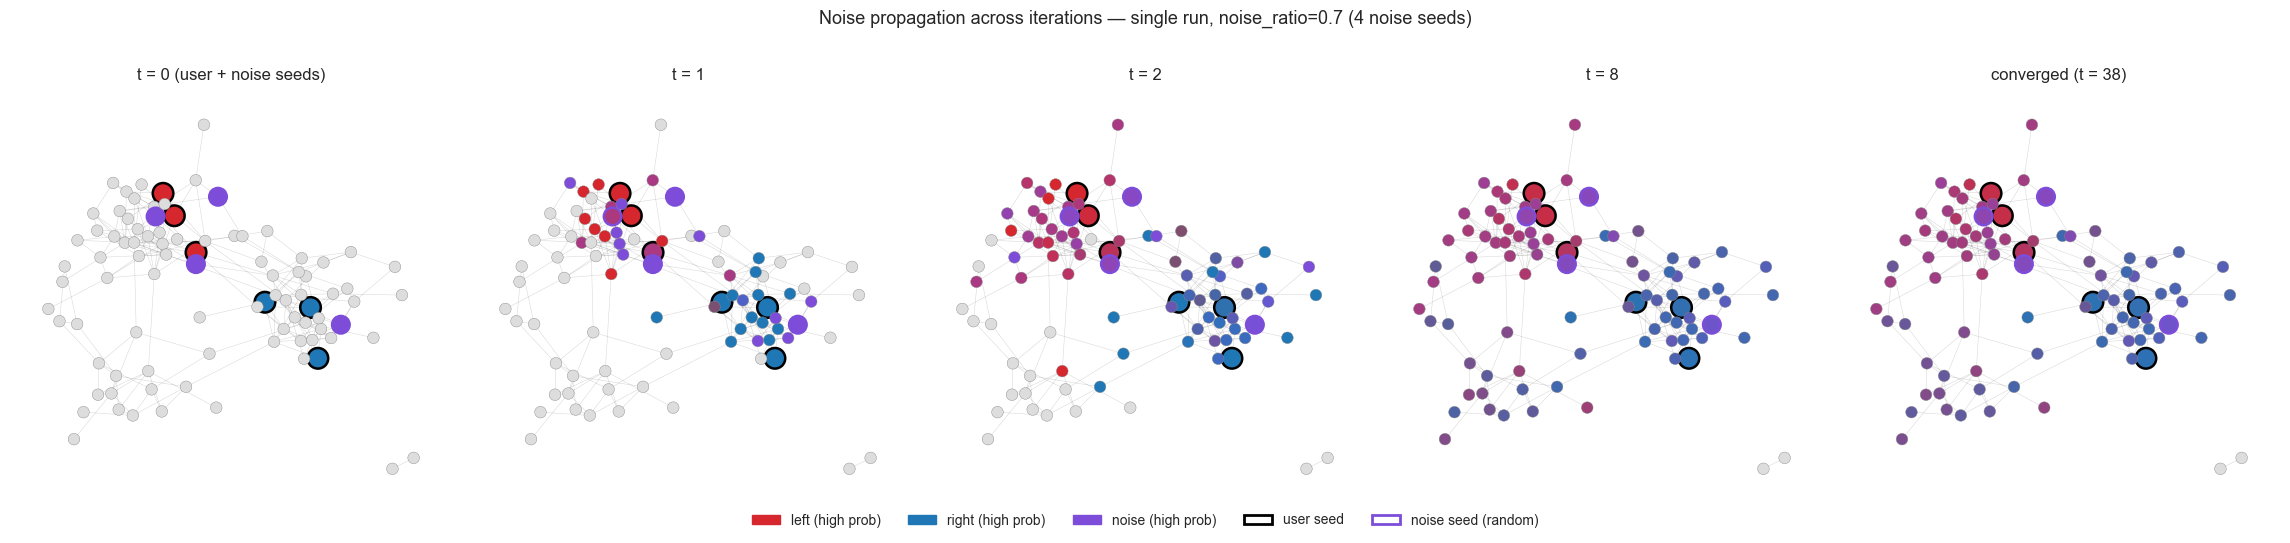

In [30]:
# Simulate noise propagation
converged_idx = len(messy_snapshots) - 1
panel_indices = [0, 1, 2, 8, converged_idx]
panel_titles = ["t = 0 (user + noise seeds)", "t = 1", "t = 2", "t = 8",
                f"converged (t = {converged_idx})"]

user_seed_set = set(messy_seeds.keys())
noise_seed_set = set(noise_seed_dict.keys())

color_left  = np.array([0.84, 0.15, 0.18])  # red
color_right = np.array([0.12, 0.47, 0.71])  # blue
color_noise = np.array([0.49, 0.30, 0.85])  # purple

node_ids_messy = [messy_mapper.get_original(i)
                  for i in range(messy_graph.numberOfNodes())]

fig, axes = plt.subplots(1, 5, figsize=(23, 5.0))
for ax, t_idx, title in zip(axes, panel_indices, panel_titles):
    F = messy_snapshots[t_idx]
    row_sums = F.sum(axis=1, keepdims=True)
    F_norm = np.where(row_sums > 0, F / np.maximum(row_sums, 1e-12), 0.0)

    colors, sizes, edgecolors, linewidths = [], [], [], []
    for i, nid in enumerate(node_ids_messy):
        if F_norm[i].sum() == 0:
            colors.append("#dddddd")
        else:
            blended = (F_norm[i, 0] * color_left
                       + F_norm[i, 1] * color_right
                       + F_norm[i, 2] * color_noise)
            colors.append(tuple(np.clip(blended, 0, 1)))

        if nid in user_seed_set:
            sizes.append(220)
            edgecolors.append("black")
            linewidths.append(1.8)
        elif nid in noise_seed_set:
            sizes.append(160)
            edgecolors.append(tuple(color_noise))
            linewidths.append(1.8)
        else:
            sizes.append(70)
            edgecolors.append("#888")
            linewidths.append(0.3)

    nx.draw_networkx_edges(G_messy, messy_pos, ax=ax, alpha=0.15, width=0.4)
    nx.draw_networkx_nodes(G_messy, messy_pos, ax=ax,
                           node_color=colors, node_size=sizes,
                           edgecolors=edgecolors, linewidths=linewidths)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

legend = [
    mpatches.Patch(color=tuple(color_left),  label="left (high prob)"),
    mpatches.Patch(color=tuple(color_right), label="right (high prob)"),
    mpatches.Patch(color=tuple(color_noise), label="noise (high prob)"),
    mpatches.Patch(facecolor="white", edgecolor="black", linewidth=2,
                   label="user seed"),
    mpatches.Patch(facecolor="white", edgecolor=tuple(color_noise),
                   linewidth=2, label="noise seed (random)"),
]
fig.legend(handles=legend, loc="lower center", ncol=5,
           bbox_to_anchor=(0.5, -0.04), frameon=False)
fig.suptitle("Noise propagation across iterations — "
             f"single run, noise_ratio=0.7 ({len(noise_seed_dict)} noise seeds)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 4. Pipeline + train/test on Facebook data
1 year Danish FB accounts sharing same URLs as politicians, news media, authorities and civil society actors.

**Four stage pipeline** — `build_edgelist` · `apply_backbone(bipartite_svn)` · `temporal_bipartite_to_unipartite` · `apply_backbone(noise_corrected)`. Polars + NetworkIt + SciPy sparse throughout.

In [31]:
# Set workspace
DATA_DIR = Path("../demo_data")
OUTPUT_DIR = Path("output"); OUTPUT_DIR.mkdir(exist_ok=True)

# ── Required files (placeholders — supply your own) ──────────────────────────
# 1. Raw FB shares — columns: page_id (str), url (str), timestamp (date/datetime).
#    Optional: n_shares (int) — used as edge weight if present.
FB_SHARES_PATH = DATA_DIR / "echo_pol_3steps_fb.csv"

# 2. Politician seeds (left/right) — columns: node_id (=page_id), label.
#    In-domain seed set for Section 4a, and cross-domain test set in Section 5.
POLITICIANS_PATH = DATA_DIR / "pol_actors_w_party.csv"
dk_party_labels = pl.read_csv(POLITICIANS_PATH).filter(~pl.col("party").is_in(["Frie Grønne","Siumut"])).drop_nulls().select(["actor_platform","party"]).rename({"actor_platform":"node_id","party":"label"})
dk_bi_labels = pl.read_csv(POLITICIANS_PATH).drop_nulls().select(["actor_platform","bi_"]).rename({"actor_platform":"node_id","bi_":"label"})

# 4. Partisan news URL/domain seeds (Section 5 content_seeds) — columns: url, label.
PARTISAN_NEWS_PATH = DATA_DIR / "danish_altmed_web_list_w_pol.csv"
dk_alt = pl.read_csv(PARTISAN_NEWS_PATH)
dk_alt = dk_alt.with_columns(pl.col("node_id").str.replace("https://", ""))
dk_alt = dk_alt.with_columns(pl.col("label").str.to_lowercase().alias("label")).filter(pl.col("label").is_in(["left","right"]))
dk_alt = dk_alt.with_columns((pl.col("node_id").str.split("/").list.get(0)).alias("domain"))
dk_alt = dk_alt.with_columns((pl.col("domain").str.split("?").list.get(0)).alias("domain"))


In [32]:
# Load real world data
shares = pl.read_csv(FB_SHARES_PATH).select(["o","e","dt","w"]).with_columns((pl.col("dt").str.slice(0,length=19).str.to_datetime("%Y-%m-%dT%H:%M:%S")).alias("dt")).sort(["o","dt"],descending=True).filter(pl.col("e")!="None_Facebook Group")
stat_users = shares.with_columns((pl.col("o").str.split("/").list.get(0)).alias("domain")).with_columns((pl.col("domain").str.split("?").list.get(0)).alias("domain")).filter(pl.col("domain").is_in(dk_alt["domain"])).select("o","e","domain").join(dk_alt,on="domain",how="left").unique(["o"])#.select("o","label").rename({"o":"node_id"})
stat_users = stat_users.group_by(["e","domain"]).agg(pl.count(),pl.first("label"))
stat_users_labels = stat_users.select(["domain","label"]).unique(["domain","label"]).rename({"domain":"node_id"})
stat_users = stat_users.select(["domain","e","count"]).rename({"e":"source_id","domain":"target_id","count":"weight"})
print(f"Loaded {shares.height:,} share events")
#print(f"Columns: {shares.columns}")
#print(f"Date range: {shares['timestamp'].min()}  →  {shares['timestamp'].max()}")
print(f"Unique pages: {shares['e'].n_unique():,}")
print(f"Unique URLs:  {shares['o'].n_unique():,}")
shares.head(5)


Loaded 21,035,585 share events
Unique pages: 28,225
Unique URLs:  16,830,862


o,e,dt,w
str,str,datetime[μs],i64
"""zzz.bedrenaetter.dk/outlet](zz…","""193551540805898_Facebook Group""",2022-12-01 09:36:14,1
"""zzwave.com/plaboard/posts/3968…","""504143656428853_Facebook Group""",2022-02-25 01:54:16,1
"""zzwave.com/plaboard/posts/3968…","""VolusiaCountyRepublicanParty_F…",2022-02-24 19:23:13,1
"""zzs-blg.blogspot.com/2022/09/c…","""121827024509492_Facebook Group""",2022-10-16 21:21:48,1
"""zzoomm.teamtailor.com/jobs/209…","""152966601945731_Facebook Group""",2022-10-17 14:36:28,1


In [33]:
# Pipeline + Network backboning
seeds_df = dk_bi_labels
result = run_canonical_pipeline(
    source=shares,
    source_col="e",
    target_col="o",
    timestamp_col="dt",
    weight_col="w",
    intermediate_col="o",
    projected_col="e",
    min_source_degree=3,
    min_target_degree=None,
    auto_weight=False,
    bipartite_overlap="drop",
    bipartite_correction="fdr_bh",
    bipartite_target_fraction=0.9,
    add_edge_weights=True,
    remove_self_loops=True,
    presort_temporal=True,
    projection_threshold=1.0,
    projection_target_fraction=0.3,
    memory_mode="balanced",
    checkpoint_dir=None,
    keep_intermediates=False,
    verbose=False,
    protected_nodes=seeds_df["node_id"].to_list(),
    bipartite_min_node_retention=0.1,
)


In [34]:
# Build final graph
# Bare definitions required by downstream cells (graph/seeds derivations).
graph, mapper = edgelist_to_graph(result.edgelist, result.id_mapper)
seed_dict = dict(zip(seeds_df["node_id"].to_list(), seeds_df["label"].to_list()))
labels = sorted(seeds_df["label"].unique().to_list())

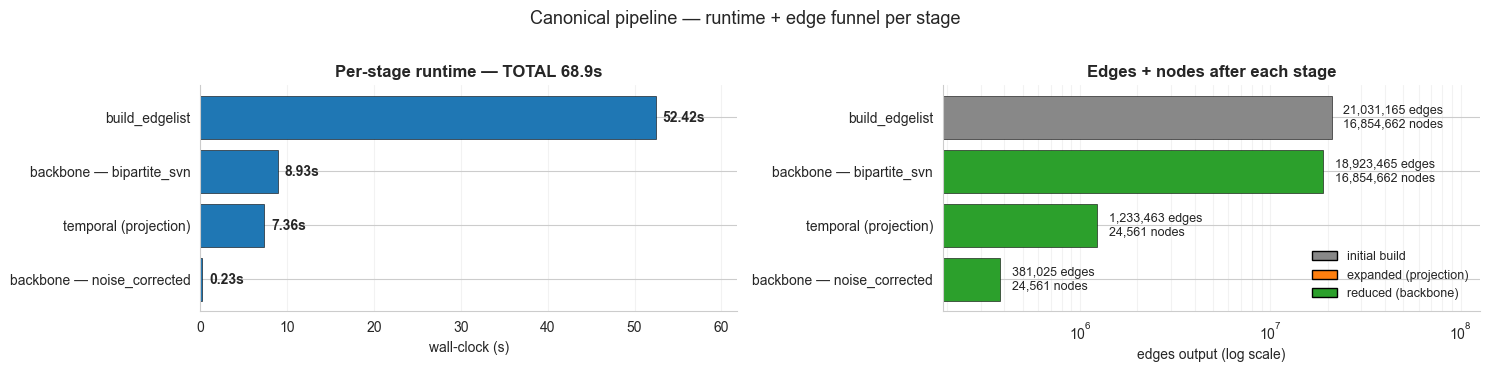

In [35]:
# Visual receipt for the "fast" claim — per-stage wall-clock + edge funnel.
# Shortened names so the y-axis stays readable.
_shorten = lambda n: (n.replace("apply_backbone(", "backbone — ").replace(")", "")
                       .replace("_from_frame", "")
                       .replace("_bipartite_to_unipartite", " (projection)"))
stage_names = [_shorten(s.name) for s in result.stage_stats]
durations    = [s.duration_s for s in result.stage_stats]
output_edges = [s.output_edges or 0 for s in result.stage_stats]
output_nodes = [s.output_nodes or 0 for s in result.stage_stats]
total_dur    = sum(durations)
y_pos        = np.arange(len(stage_names))

fig, (ax_dur, ax_e) = plt.subplots(
    1, 2, figsize=(15, max(3.5, 0.9 * len(stage_names))),
)

# --- Left panel: per-stage runtime ---
ax_dur.barh(y_pos, durations, color="#1f77b4",
            edgecolor="black", linewidth=0.4)
for y, d in zip(y_pos, durations):
    ax_dur.text(d + max(durations) * 0.015, y, f"{d:.2f}s",
                va="center", fontsize=10, fontweight="bold")
ax_dur.invert_yaxis()
ax_dur.set_yticks(y_pos)
ax_dur.set_yticklabels(stage_names, fontsize=10)
ax_dur.set_xlabel("wall-clock (s)")
ax_dur.set_xlim(0, max(durations) * 1.18)
ax_dur.set_title(f"Per-stage runtime — TOTAL {total_dur:.1f}s",
                 fontsize=12, fontweight="bold")
ax_dur.spines["top"].set_visible(False)
ax_dur.spines["right"].set_visible(False)
ax_dur.grid(axis="x", alpha=0.25)

# --- Right panel: output edges (log scale, colored by direction of change) ---
prev = None; colors = []
for oe in output_edges:
    if prev is None:
        colors.append("#888888")          # initial build
    elif oe > prev:
        colors.append("#ff7f0e")          # expanded (projection)
    else:
        colors.append("#2ca02c")          # reduced (backbone)
    prev = oe

ax_e.barh(y_pos, output_edges, color=colors,
          edgecolor="black", linewidth=0.4)
for y, oe, on in zip(y_pos, output_edges, output_nodes):
    if oe:
        ax_e.text(oe * 1.15, y, f"{oe:,} edges\n{on:,} nodes",
                  va="center", fontsize=9)
ax_e.invert_yaxis()
ax_e.set_yticks(y_pos)
ax_e.set_yticklabels(stage_names, fontsize=10)
ax_e.set_xscale("log")
ax_e.set_xlim(min(o for o in output_edges if o) / 2,
              max(output_edges) * 6)
ax_e.set_xlabel("edges output (log scale)")
ax_e.set_title("Edges + nodes after each stage",
               fontsize=12, fontweight="bold")
ax_e.spines["top"].set_visible(False)
ax_e.spines["right"].set_visible(False)
ax_e.grid(axis="x", alpha=0.25, which="both")

from matplotlib.patches import Patch
ax_e.legend(handles=[
    Patch(facecolor="#888888", edgecolor="black", label="initial build"),
    Patch(facecolor="#ff7f0e", edgecolor="black", label="expanded (projection)"),
    Patch(facecolor="#2ca02c", edgecolor="black", label="reduced (backbone)"),
], loc="lower right", fontsize=9, frameon=False)

fig.suptitle("Canonical pipeline — runtime + edge funnel per stage",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 4a. Held-out train/test — left/right
- 20% stratified holdout · `directional_pass="out"` · `noise_ratio=0.3`

**Error split**
- `noise_errors` — model said *"I'm not sure"* → recoverable
- `hard_errors` — model picked the wrong real label confidently → real failure

In [36]:
# Validation left/right politicians
val_results = train_test_split_validation(
    graph=graph,
    id_mapper=mapper,
    seed_labels=seeds_df,
    labels=list(set(seeds_df["label"].to_list())),
    test_size=0.5,
    stratify=True,
    random_seed=43,
    # GLP kwargs passed through:
    alpha=0.85,
    directional=True,
    directional_pass="out",
    enable_noise_category=True,
    noise_ratio=.75,
    propagator=ensemble_label_propagation,
    distance_prior=False,
    max_iterations=1500,
    n_epochs=30,
    weight_transform=winsorize_transform(cap=10),
)


[ensemble_label_propagation] 2.01s | nodes=24,561 edges=381,025 | seeds=78 labels=2 alpha=0.85 epochs=30 | output=directional (tuple)


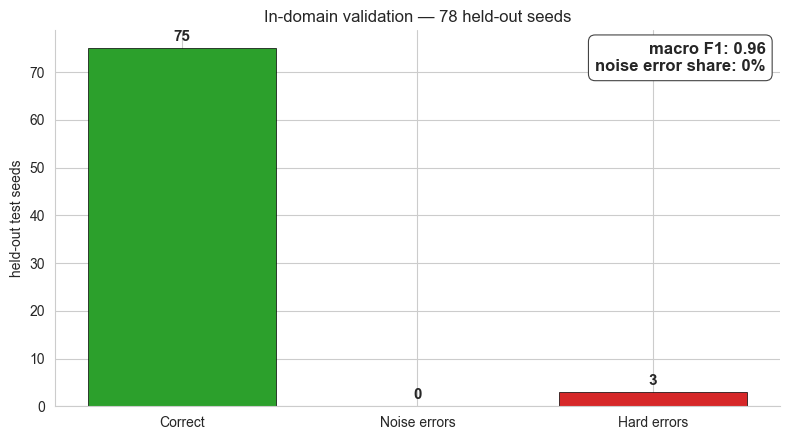

In [37]:
# Number of errors — in-domain (left/right) train/test breakdown.
counts = {
    "Correct":      int(round(val_results["accuracy"] * val_results["test_size"])),
    "Noise errors": int(val_results["noise_errors"]),
    "Hard errors":  int(val_results["hard_errors"]),
}
macro_f1    = val_results["macro_f1"]
noise_share = val_results["noise_error_share"]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(counts.keys(), counts.values(),
              color=["#2ca02c", "#bbbbbb", "#d62728"],
              edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + max(counts.values()) * 0.02,
            f"{val}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("held-out test seeds")

# Headline metrics — boxed annotation, prominent in the upper-right.
ax.text(0.98, 0.97,
        f"macro F1: {macro_f1:.2f}\nnoise error share: {noise_share:.0%}",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=12, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="#444", linewidth=0.8))

ax.set_title(f"In-domain validation — {val_results['test_size']} held-out seeds")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### 4b. Multi-class — party affiliation (10 classes)
- Same setup, label = party name
- **Heavily unbalanced** — largest 40+ members, smallest 4
- $(1{-}\alpha)Y$ anchor keeps each seed at 1.0 → no per-class re-weighting needed

In [38]:
# Multi-class run — same kwargs as 4a, only the seed labels change.
party_seeds_df = dk_party_labels
party_val = train_test_split_validation(
    graph=graph,
    id_mapper=mapper,
    seed_labels=party_seeds_df,
    labels=list(set(party_seeds_df["label"].to_list())),
    test_size=0.4,
    stratify=True,
    random_seed=42,
    # GLP kwargs passed through:
    alpha=0.85,
    directional=True,
    directional_pass="out",
    enable_noise_category=True,
    noise_ratio=0.7,
    propagator=ensemble_label_propagation,
    distance_prior=False,
    max_iterations=1500,
    n_epochs=30,
    weight_transform=winsorize_transform(cap=10),
)


[ensemble_label_propagation] 6.54s | nodes=24,561 edges=381,025 | seeds=92 labels=11 alpha=0.85 epochs=30 | output=directional (tuple)


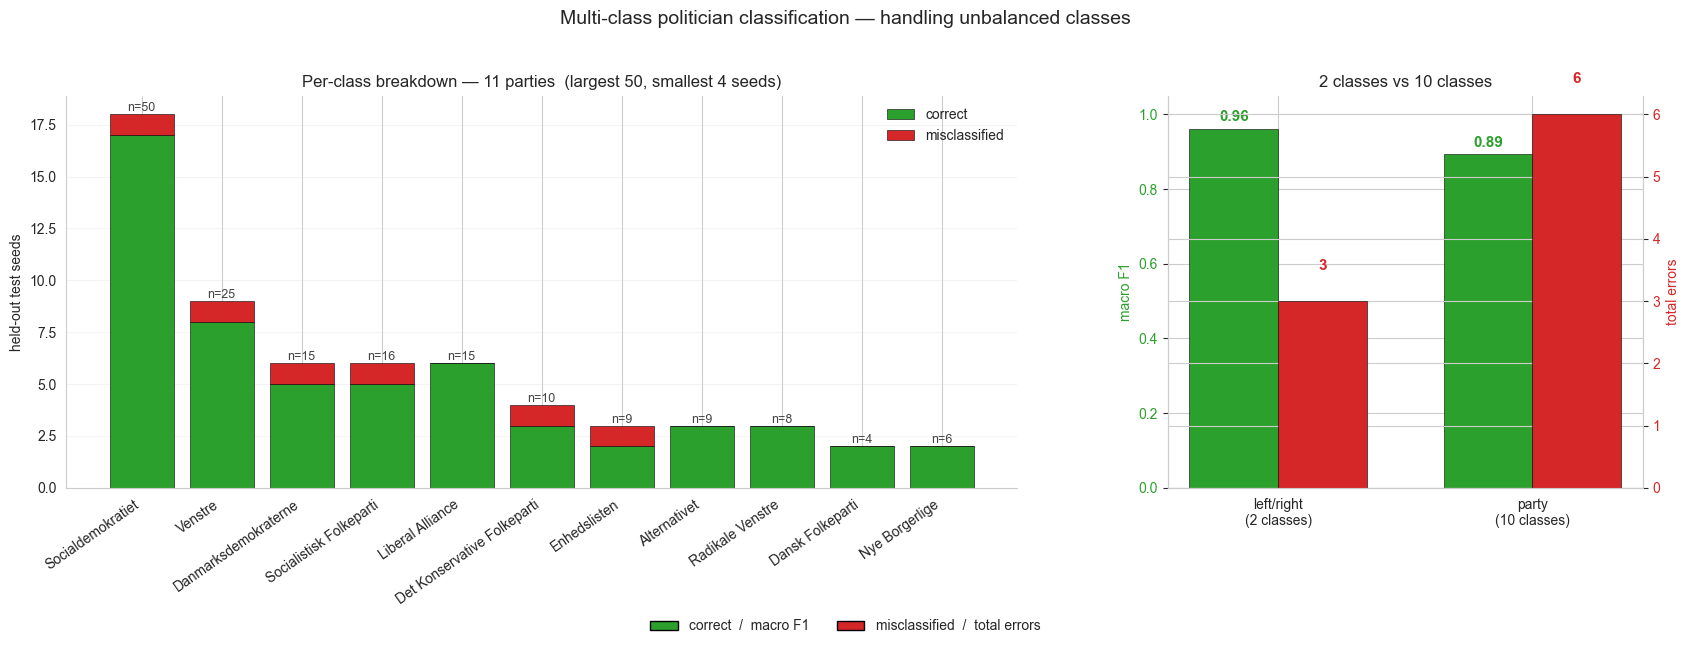

In [39]:
# Per-class accuracy from the held-out predictions.
party_seed_dict = dict(zip(party_seeds_df['node_id'].to_list(), party_seeds_df['label'].to_list()))
test_preds = party_val["test_predictions"].with_columns(
    true_label=pl.col("node_id").map_elements(
        lambda nid: party_seed_dict.get(nid), return_dtype=pl.Utf8),
).with_columns(
    correct=(pl.col("dominant_label") == pl.col("true_label")),
)
per_class = (
    test_preds.group_by("true_label")
    .agg(n_correct=pl.col("correct").sum(),
         n_test=pl.len())
    .with_columns(n_wrong=pl.col("n_test") - pl.col("n_correct"))
    .sort("n_test", descending=True)
)
# Total seeds per class (for the n=... annotations).
class_total = dict(zip(
    party_seeds_df["label"].value_counts().sort("count", descending=True)["label"].to_list(),
    party_seeds_df["label"].value_counts().sort("count", descending=True)["count"].to_list(),
))

# === Figure: per-class breakdown (left) + 2-class vs 10-class comparison (right) ===
fig = plt.figure(figsize=(17, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[2.0, 0.05, 1.0])
ax_main = fig.add_subplot(gs[0, 0])
ax_cmp  = fig.add_subplot(gs[0, 2])

# --- Left panel: per-class stacked bars
class_names = per_class["true_label"].to_list()
n_correct = per_class["n_correct"].to_list()
n_wrong = per_class["n_wrong"].to_list()
x_pos = np.arange(len(class_names))

ax_main.bar(x_pos, n_correct, color="#2ca02c", edgecolor="black",
            linewidth=0.4, label="correct")
ax_main.bar(x_pos, n_wrong, bottom=n_correct, color="#d62728", edgecolor="black",
            linewidth=0.4, label="misclassified")

for i, name in enumerate(class_names):
    total = class_total.get(name, 0)
    height = n_correct[i] + n_wrong[i]
    ax_main.text(i, height + 0.15, f"n={total}", ha="center", fontsize=9, color="#444")

ax_main.set_xticks(x_pos)
ax_main.set_xticklabels(class_names, rotation=35, ha="right")
ax_main.set_ylabel("held-out test seeds")
sizes = [class_total.get(n, 0) for n in class_names]
ax_main.set_title(f"Per-class breakdown — {len(class_names)} parties  "
                  f"(largest {max(sizes)}, smallest {min(sizes)} seeds)")
ax_main.legend(loc="upper right", frameon=False)
ax_main.spines["top"].set_visible(False)
ax_main.spines["right"].set_visible(False)
ax_main.grid(axis="y", alpha=0.2)

# --- Right panel: 2-class vs 10-class comparison
metrics = ["left/right\n(2 classes)", "party\n(10 classes)"]
f1_vals = [val_results["macro_f1"], party_val["macro_f1"]]
err_vals = [val_results["total_errors"], party_val["total_errors"]]
x_pos_cmp = np.arange(len(metrics))
width = 0.35

bars_f1 = ax_cmp.bar(x_pos_cmp - width / 2, f1_vals, width,
                     color="#2ca02c", edgecolor="black", linewidth=0.4)
ax_cmp.set_ylim(0, 1.05)
ax_cmp.set_ylabel("macro F1", color="#2ca02c")
ax_cmp.tick_params(axis="y", labelcolor="#2ca02c")
for bar, v in zip(bars_f1, f1_vals):
    ax_cmp.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.2f}",
                ha="center", fontsize=11, fontweight="bold", color="#2ca02c")

ax2_cmp = ax_cmp.twinx()
bars_err = ax2_cmp.bar(x_pos_cmp + width / 2, err_vals, width,
                       color="#d62728", edgecolor="black", linewidth=0.4)
ax2_cmp.set_ylabel("total errors", color="#d62728")
ax2_cmp.tick_params(axis="y", labelcolor="#d62728")
for bar, v in zip(bars_err, err_vals):
    ax2_cmp.text(bar.get_x() + bar.get_width() / 2, v + 0.5, f"{int(v)}",
                 ha="center", fontsize=11, fontweight="bold", color="#d62728")

ax_cmp.set_xticks(x_pos_cmp)
ax_cmp.set_xticklabels(metrics)
ax_cmp.set_title("2 classes vs 10 classes")
ax_cmp.spines["top"].set_visible(False)
ax2_cmp.spines["top"].set_visible(False)

# Combined legend below the figure
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, fc="#2ca02c", ec="black"),
    plt.Rectangle((0, 0), 1, 1, fc="#d62728", ec="black"),
]
fig.legend(legend_handles, ["correct  /  macro F1", "misclassified  /  total errors"],
           loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.04))

fig.suptitle("Multi-class politician classification — handling unbalanced classes",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4c. The `noise_ratio` knob — swept
- `noise_ratio` ∈ {0, 0.1, 0.3, 0.5, 1.0} · `n_repeats=3`
- ↑ `noise_ratio` → noise absorbs uncertain mass · `noise_errors` ↑ · `hard_errors` ↓
- Optimum = `macro_f1` peak

In [40]:
grid = GLPGridSearch(
    graph=graph,
    id_mapper=mapper,
    seed_labels=seeds_df,
    labels=labels,
    # Sweep noise_ratio; everything else fixed.
    noise_ratio_grid=[0.5, 1.0, 1.5, 2.0, 2.5, 3.0],
    alpha_grid=[0.85],
    test_size_grid=[0.2],
    # Single GLP per cell (n_epochs_grid=[1]) keeps the sweep snappy on real
    # data — change to e.g. [10] to switch to noise-resampled ensembling.
    n_epochs_grid=[1],
    n_repeats=3,
    random_seed=42,
    stratify=True,
    directional=True,
    directional_pass="out",
    enable_noise_category=True,
    verbose=False,
)
grid_df = grid.run()
summary = grid.summary(sort_by="noise_ratio", descending=False)


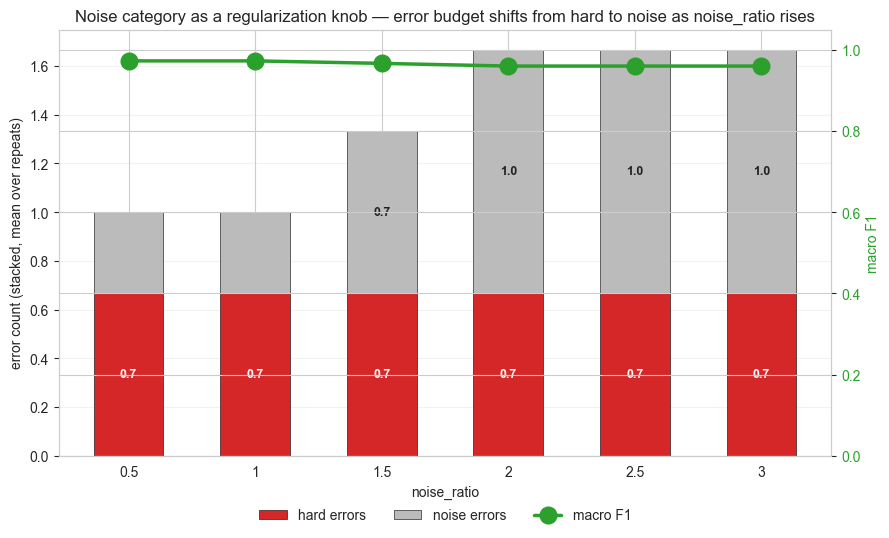

In [41]:
# Show noise
xs = summary["noise_ratio"].to_list()
hard = summary["hard_errors_mean"].to_list()
noise = summary["noise_errors_mean"].to_list()
f1 = summary["macro_f1_mean"].to_list()

# Categorical x positions so the uneven noise_ratio spacing doesn't squish
# the leftmost bars together.
x_pos = np.arange(len(xs))
x_labels = [f"{x:g}" for x in xs]

fig, ax1 = plt.subplots(figsize=(9, 5.2))

# Stacked bars: hard at bottom, noise on top. Total height = total errors.
ax1.bar(x_pos, hard, width=0.55, color="#d62728", edgecolor="black",
        linewidth=0.4, label="hard errors")
ax1.bar(x_pos, noise, width=0.55, bottom=hard, color="#bbbbbb",
        edgecolor="black", linewidth=0.4, label="noise errors")

# Annotate counts on each segment (skip tiny ones to avoid clutter).
for x, h, n in zip(x_pos, hard, noise):
    if h >= 0.5:
        ax1.text(x, h / 2, f"{h:.1f}", ha="center", va="center",
                 fontsize=9, color="white", fontweight="bold")
    if n >= 0.5:
        ax1.text(x, h + n / 2, f"{n:.1f}", ha="center", va="center",
                 fontsize=9, color="#222", fontweight="bold")

ax1.set_xlabel("noise_ratio")
ax1.set_ylabel("error count (stacked, mean over repeats)")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x_labels)
ax1.grid(True, axis="y", alpha=0.25)

# Macro F1 on the twin axis.
ax2 = ax1.twinx()
ax2.plot(x_pos, f1, "o-", color="#2ca02c", linewidth=2.5, markersize=12,
         label="macro F1")
ax2.set_ylabel("macro F1", color="#2ca02c")
ax2.tick_params(axis="y", labelcolor="#2ca02c")
ax2.set_ylim(0, 1.05)

# Combined legend BELOW the plot — never overlaps the data.
lines, labs = [], []
for ax in (ax1, ax2):
    h, l = ax.get_legend_handles_labels()
    lines += h; labs += l
fig.legend(lines, labs, loc="lower center", ncol=3, frameon=False,
           bbox_to_anchor=(0.5, -0.04))

ax1.set_title("Noise category as a regularization knob — "
              "error budget shifts from hard to noise as noise_ratio rises")
plt.tight_layout()
plt.show()

## 5. Cross-domain: partisan news → politicians
**Seeds** content side (URLs) · **Test set** page side (politicians) — disjoint by construction.

### Stat-user augmentation
- Each labelled URL $c$ → synthetic anchor `__stat__c` connected to pages that shared $c$
- Anchors live in the **page partition** of the projection → GLP on clean page space
- $(1{-}\alpha)Y$ keeps anchors fixed throughout

`run_canonical_pipeline(content_seeds=stat_edges, protected_nodes=stat_ids)` attaches anchors before the projection backbone.

In [42]:
cross_result = run_canonical_pipeline(
    source=shares,
    source_col="e",
    target_col="o",
    timestamp_col="dt",
    weight_col="w",
    intermediate_col="o",
    projected_col="e",
    min_source_degree=3,
    min_target_degree=None,
    auto_weight=False,
    bipartite_overlap="drop",
    bipartite_alpha=0.005,
    bipartite_correction="fdr_bh",
    bipartite_target_fraction=0.9,
    add_edge_weights=True,
    remove_self_loops=True,
    presort_temporal=True,
    projection_threshold=1.0,
    projection_target_fraction=0.3,
    memory_mode="balanced",
    checkpoint_dir=None,
    keep_intermediates=False,
    verbose=False,
    protected_nodes=seeds_df["node_id"].to_list(),
    bipartite_min_node_retention=0.1,
    content_seeds=stat_users
)
cross_graph, cross_mapper = edgelist_to_graph(
    cross_result.edgelist, cross_result.id_mapper,
)

In [43]:
#cross_labels = sorted(set(stat_seeds.values()))
cross_val = train_test_split_validation(
    graph=cross_graph,
    id_mapper=cross_mapper,
    seed_labels=stat_users_labels,
    labels=list(set(seeds_df["label"].to_list())),
    test_size=0.3,
    stratify=True,
    random_seed=42,
    # GLP kwargs passed through:
    alpha=0.95,
    directional=True,
    directional_pass="out",
    enable_noise_category=True,
    noise_ratio=.5,
    propagator=ensemble_label_propagation,
    distance_prior=False,
    max_iterations=1500,
    n_epochs=40,
    weight_transform=winsorize_transform(cap=10),
    test_seeds=seeds_df
)


[ensemble_label_propagation] 2.03s | nodes=24,585 edges=381,439 | seeds=12 labels=2 alpha=0.95 epochs=40 | output=directional (tuple)


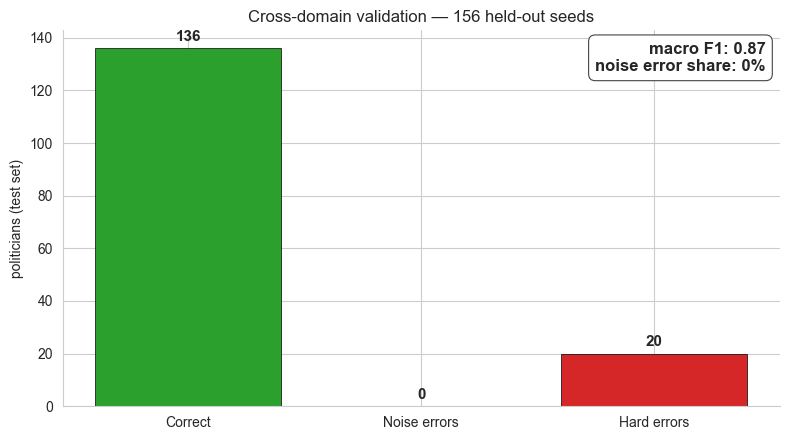

In [44]:
# Number of errors — cross-domain (partisan news → politicians).
counts = {
    "Correct":      int(round(cross_val["accuracy"] * cross_val["test_size"])),
    "Noise errors": int(cross_val["noise_errors"]),
    "Hard errors":  int(cross_val["hard_errors"]),
}
macro_f1    = cross_val["macro_f1"]
noise_share = cross_val["noise_error_share"]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(counts.keys(), counts.values(),
              color=["#2ca02c", "#bbbbbb", "#d62728"],
              edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + max(counts.values()) * 0.02,
            f"{val}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("politicians (test set)")

# Headline metrics — boxed annotation, prominent in the upper-right.
ax.text(0.98, 0.97,
        f"macro F1: {macro_f1:.2f}\nnoise error share: {noise_share:.0%}",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=12, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="#444", linewidth=0.8))

ax.set_title(f"Cross-domain validation — {cross_val['test_size']} held-out seeds")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Visualization + Gephi export
- Louvain consensus (×5, undirected) — unsupervised baseline
- PPR top-400 neighborhood of seeds — plottable subgraph
- Three matplotlib panels — Louvain · GLP dominant · GLP noise
- GEXF — typed attributes, opens directly in Gephi

In [45]:
# Full-graph GLP — same setup as Section 4 (in-domain seeds).
full_out, full_in = guided_label_propagation(
    graph=cross_graph,
    id_mapper=cross_mapper,
    seed_labels=stat_users_labels,
    labels=list(set(seeds_df["label"].to_list())),
    alpha=0.85,
    directional=True,
    enable_noise_category=True,
    noise_ratio=0.7,
)
print(f"GLP on {graph.numberOfNodes():,} nodes — out-pass dominant_label counts:")
display(full_out["dominant_label"].value_counts())

# Full-graph Louvain (consensus over 5 runs).
# NetworkIt's PLM requires undirected; our `graph` is the directed temporal
# projection, so convert first. toUndirected preserves internal node IDs so
# `mapper` still works.
g_louvain = nk.graphtools.toUndirected(graph) if graph.isDirected() else graph
communities = detect_communities(
    graph=g_louvain, id_mapper=mapper,
    algorithm="louvain", iterations=5, random_seed=42, n_jobs=1,
)
n_cons = communities["community_consensus"].n_unique()
print(f"\nLouvain consensus: {n_cons} communities across {communities.height:,} nodes")


[guided_label_propagation] 0.40s | nodes=24,585 edges=381,439 | seeds=12 labels=2 alpha=0.85 | output=directional (tuple)
GLP on 24,561 nodes — out-pass dominant_label counts:


dominant_label,count
str,u32
"""noise""",5407
"""left""",15205
"""right""",3973



Louvain consensus: 78 communities across 24,561 nodes


In [46]:
# PPR neighborhood of the seeds, for a plottable subgraph.
sub_graph, sub_mapper = filter_by_seed_proximity(
    graph=graph, id_mapper=mapper,
    seeds=list(seed_dict.keys()),
    method="ppr",
    ppr_alpha=0.85,
    top_n=400,
    include_seeds=True,
)
print(f"Reduced subgraph: {sub_graph.numberOfNodes()} nodes, "
      f"{sub_graph.numberOfEdges()} edges")

# Layout once — reused across all three panels.
if HAS_NX:
    G_sub = nx.DiGraph() if sub_graph.isDirected() else nx.Graph()
    for i in range(sub_graph.numberOfNodes()):
        G_sub.add_node(sub_mapper.get_original(i))
    for u, v in sub_graph.iterEdges():
        G_sub.add_edge(sub_mapper.get_original(u), sub_mapper.get_original(v))
    sub_layout = nx.spring_layout(G_sub, seed=42, k=0.3, iterations=80)
    print("Layout ready.")
else:
    print("Install networkx for the visualization step.")


Reduced subgraph: 400 nodes, 5285 edges
Layout ready.


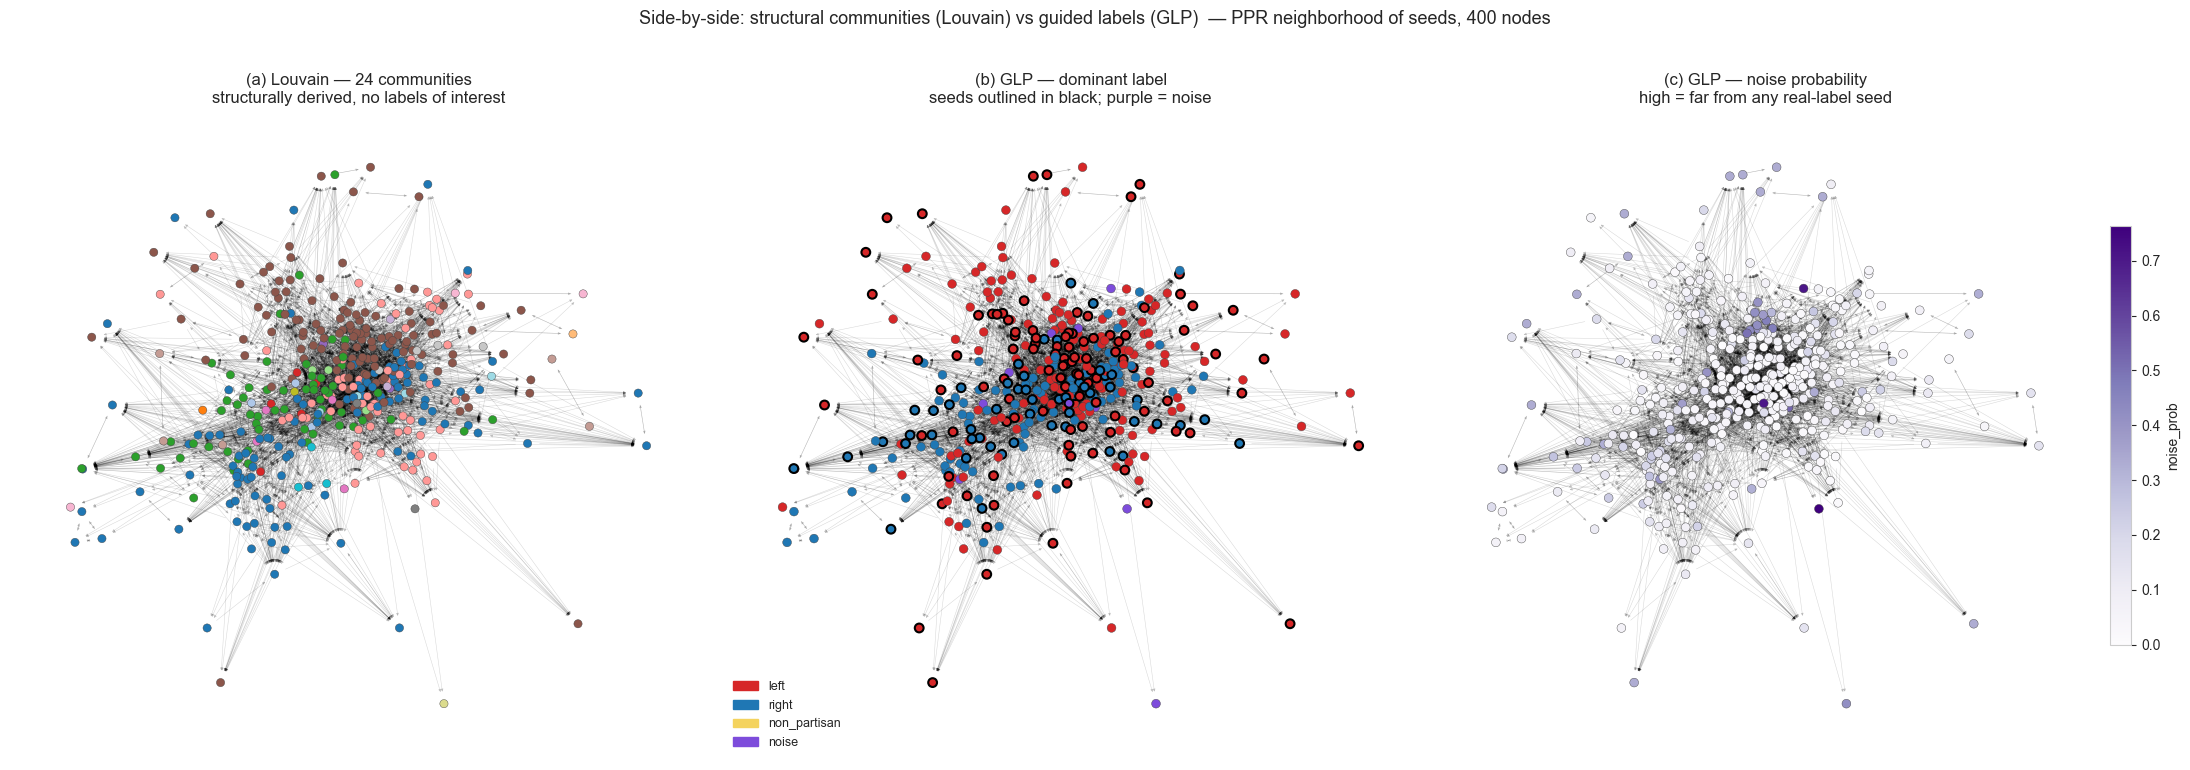

In [47]:
if HAS_NX:
    sub_node_ids = [sub_mapper.get_original(i)
                    for i in range(sub_graph.numberOfNodes())]
    sub_df = pl.DataFrame({"node_id": sub_node_ids})

    sub_lou = sub_df.join(
        communities.select(["node_id", "community_consensus"]),
        on="node_id", how="left",
    )
    sub_glp = sub_df.join(full_out, on="node_id", how="left")

    seed_set = set(seed_dict.keys())

    fig, axes = plt.subplots(1, 3, figsize=(22, 7.5))

    # ── Panel A — Louvain ─────────────────────────────────────────────────
    ax = axes[0]
    lou_communities = sub_lou["community_consensus"].to_list()
    unique_lou = sorted({c for c in lou_communities if c is not None})
    lou_palette = plt.cm.tab20(np.linspace(0, 1, max(len(unique_lou), 1)))
    lou_colors = [
        "#dddddd" if c is None
        else lou_palette[unique_lou.index(c) % len(lou_palette)]
        for c in lou_communities
    ]
    nx.draw_networkx_edges(G_sub, sub_layout, ax=ax, alpha=0.15, width=0.4,
                           arrowsize=4 if sub_graph.isDirected() else 0)
    nx.draw_networkx_nodes(G_sub, sub_layout, ax=ax,
                           node_color=lou_colors, node_size=35,
                           edgecolors="#444", linewidths=0.3)
    ax.set_title(f"(a) Louvain — {len(unique_lou)} communities\n"
                 "structurally derived, no labels of interest", fontsize=12)
    ax.axis("off")

    # ── Panel B — GLP dominant label ──────────────────────────────────────
    ax = axes[1]
    glp_palette = {"left": "#d62728", "right": "#1f77b4",
                   "non_partisan": "#f4d35e", "noise": "#7d4cdb"}
    dom_labels = sub_glp["dominant_label"].to_list()
    glp_colors = [glp_palette.get(d, "#dddddd") for d in dom_labels]
    edgecolors = ["black" if nid in seed_set else "#444"
                  for nid in sub_node_ids]
    linewidths = [1.5 if nid in seed_set else 0.3 for nid in sub_node_ids]
    nx.draw_networkx_edges(G_sub, sub_layout, ax=ax, alpha=0.15, width=0.4,
                           arrowsize=4 if sub_graph.isDirected() else 0)
    nx.draw_networkx_nodes(G_sub, sub_layout, ax=ax,
                           node_color=glp_colors, node_size=40,
                           edgecolors=edgecolors, linewidths=linewidths)
    ax.set_title("(b) GLP — dominant label\n"
                 "seeds outlined in black; purple = noise", fontsize=12)
    ax.axis("off")
    glp_legend = [mpatches.Patch(color=c, label=l)
                  for l, c in glp_palette.items()]
    ax.legend(handles=glp_legend, loc="lower left", fontsize=9, frameon=False)

    # ── Panel C — GLP noise score ─────────────────────────────────────────
    ax = axes[2]
    noise_col = "noise_prob" if "noise_prob" in sub_glp.columns else None
    if noise_col is None:
        ax.text(0.5, 0.5, "No noise column in result — re-run GLP with\n"
                          "enable_noise_category=True.",
                transform=ax.transAxes, ha="center", va="center")
        ax.axis("off")
    else:
        noise_probs = sub_glp[noise_col].fill_null(0.0).to_list()
        nx.draw_networkx_edges(G_sub, sub_layout, ax=ax, alpha=0.15,
                               width=0.4,
                               arrowsize=4 if sub_graph.isDirected() else 0)
        nodes = nx.draw_networkx_nodes(G_sub, sub_layout, ax=ax,
                                       node_color=noise_probs,
                                       cmap="Purples", node_size=40,
                                       edgecolors="#444", linewidths=0.3,
                                       vmin=0,
                                       vmax=max(0.05, max(noise_probs)))
        fig.colorbar(nodes, ax=ax, fraction=0.03, pad=0.02,
                     label="noise_prob")
        ax.set_title("(c) GLP — noise probability\n"
                     "high = far from any real-label seed", fontsize=12)
        ax.axis("off")

    fig.suptitle(
        "Side-by-side: structural communities (Louvain) vs guided labels (GLP)  "
        f"— PPR neighborhood of seeds, {sub_graph.numberOfNodes()} nodes",
        fontsize=13, y=1.02,
    )
    plt.tight_layout()
    plt.show()


### 6a. Gephi-ready export
`export_reduced_graph(method="influence", target_nodes=2000)` — real page nodes, no aggregation.
All attrs typed (`double` / `boolean` / `string`) → sliders + filters work directly in Gephi.

In [48]:
gexf_path = OUTPUT_DIR / "dk_fb_reduced.gexf"
# Influence-based reduction: apply_backbone (default noise_corrected) keeps
# the highest-leverage real nodes — preserves page identity, no aggregation.
# Works on directed graphs; no undirected conversion needed.
returned_path, reduced_g, reduced_mapper, node_attrs = export_reduced_graph(
    graph=graph,
    id_mapper=mapper,
    output_path=gexf_path,
    method="influence",
    glp_results=(full_out, full_in),
    glp_direction="out",
    target_nodes=2000,
    format="gexf",
    overwrite=True,
    return_reduced=True,
)
print(f"\nWrote {returned_path}")
print(f"Reduced graph: {reduced_g.numberOfNodes()} nodes, "
      f"{reduced_g.numberOfEdges()} edges")
print("\nFirst 5 nodes (preview of what's in the GEXF):")
display(node_attrs.head(5))


Wrote output/dk_fb_reduced.gexf
Reduced graph: 2000 nodes, 30452 edges

First 5 nodes (preview of what's in the GEXF):


node_id,left_prob,right_prob,noise_prob,dominant_label,confidence,is_seed
str,f64,f64,f64,str,f64,bool
"""100044360022428_Facebook Page""",0.353378,0.547202,0.09942,"""right""",0.547202,false
"""100063532930637_Facebook Page""",0.370914,0.06771,0.561376,"""noise""",0.561376,false
"""100063590635452_Facebook Page""",0.176417,0.677026,0.146558,"""right""",0.677026,false
"""100063643303178_Facebook Page""",0.961074,0.032546,0.00638,"""left""",0.961074,false
"""100063653915974_Facebook Page""",0.615654,0.251797,0.132549,"""left""",0.615654,false


## 7. Limitations 

- Tuning is needed to gurantee best results, many hyperparameters (still no free lunch)  
  
- If you have very large data, you still need a large machine

**See also** - 